In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

load_dotenv('../.env')

df = pd.read_csv('../data/raw/Ecom.csv', encoding='unicode_escape')

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
null_rates=df.isnull().sum()/len(df)*100
print(null_rates)

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


In [12]:
df.select_dtypes(include="str").nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
InvoiceDate    23260
Country           38
dtype: int64

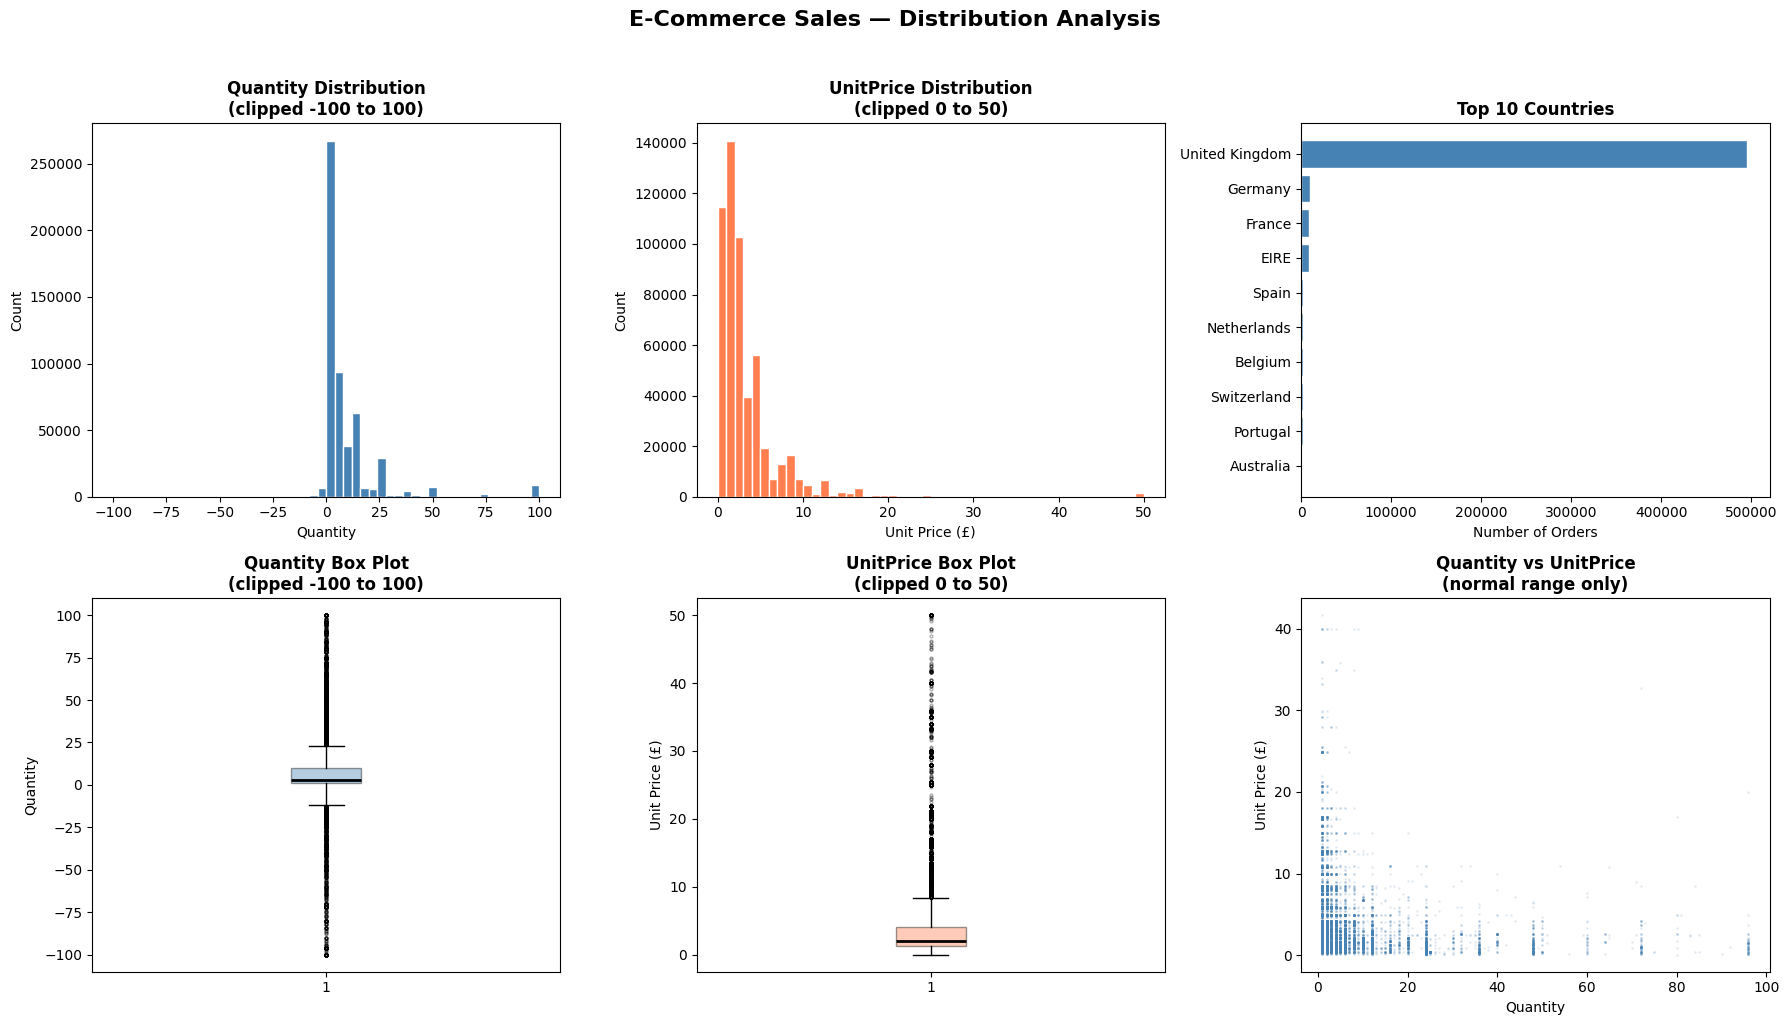

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Quantity distribution (clipped to see normal range)
axes[0,0].hist(
    df['Quantity'].clip(-100, 100), 
    bins=50, 
    color='steelblue', 
    edgecolor='white'
)
axes[0,0].set_title('Quantity Distribution\n(clipped -100 to 100)', fontweight='bold')
axes[0,0].set_xlabel('Quantity')
axes[0,0].set_ylabel('Count')

# 2 — UnitPrice distribution (clipped to see normal range)
axes[0,1].hist(
    df['UnitPrice'].clip(0, 50), 
    bins=50, 
    color='coral', 
    edgecolor='white'
)
axes[0,1].set_title('UnitPrice Distribution\n(clipped 0 to 50)', fontweight='bold')
axes[0,1].set_xlabel('Unit Price (£)')
axes[0,1].set_ylabel('Count')

# 3 — Top 10 countries
top_countries = df['Country'].value_counts().head(10)
axes[0,2].barh(
    top_countries.index[::-1], 
    top_countries.values[::-1],
    color='steelblue',
    edgecolor='white'
)
axes[0,2].set_title('Top 10 Countries', fontweight='bold')
axes[0,2].set_xlabel('Number of Orders')

# 4 — Quantity box plot (clipped)
axes[1,0].boxplot(
    df['Quantity'].clip(-100, 100),
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.4),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
axes[1,0].set_title('Quantity Box Plot\n(clipped -100 to 100)', fontweight='bold')
axes[1,0].set_ylabel('Quantity')

# 5 — UnitPrice box plot (clipped)
axes[1,1].boxplot(
    df['UnitPrice'].clip(0, 50),
    patch_artist=True,
    boxprops=dict(facecolor='coral', alpha=0.4),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
axes[1,1].set_title('UnitPrice Box Plot\n(clipped 0 to 50)', fontweight='bold')
axes[1,1].set_ylabel('Unit Price (£)')

# 6 — Quantity vs UnitPrice scatter (normal range only)
mask = (
    (df['Quantity'] > 0) & 
    (df['Quantity'] < 100) & 
    (df['UnitPrice'] > 0) & 
    (df['UnitPrice'] < 50)
)
sample = df[mask].sample(n=min(20000, mask.sum()), random_state=42)
axes[1,2].scatter(
    sample['Quantity'],
    sample['UnitPrice'],
    alpha=0.1,
    s=1,
    color='steelblue'
)
axes[1,2].set_title('Quantity vs UnitPrice\n(normal range only)', fontweight='bold')
axes[1,2].set_xlabel('Quantity')
axes[1,2].set_ylabel('Unit Price (£)')

plt.suptitle('E-Commerce Sales — Distribution Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
print("OUTLIER SUMMARY\n" + "="*40)

neg_qty = (df['Quantity'] < 0).sum()
zero_qty = (df['Quantity'] == 0).sum()
extreme_qty = (df['Quantity'] > df['Quantity'].quantile(0.99)).sum()

neg_price = (df['UnitPrice'] < 0).sum()
zero_price = (df['UnitPrice'] == 0).sum()
extreme_price = (df['UnitPrice'] > df['UnitPrice'].quantile(0.99)).sum()

print(f"Quantity negative:          {neg_qty:,} rows")
print(f"Quantity zero:              {zero_qty:,} rows")
print(f"Quantity above 99th pct:   {extreme_qty:,} rows")
print()
print(f"UnitPrice negative:         {neg_price:,} rows")
print(f"UnitPrice zero:             {zero_price:,} rows")
print(f"UnitPrice above 99th pct:  {extreme_price:,} rows")
print()
print(f"99th percentile Quantity:  {df['Quantity'].quantile(0.99):.0f}")
print(f"99th percentile UnitPrice: £{df['UnitPrice'].quantile(0.99):.2f}")

OUTLIER SUMMARY
Quantity negative:          10,624 rows
Quantity zero:              0 rows
Quantity above 99th pct:   4,950 rows

UnitPrice negative:         2 rows
UnitPrice zero:             2,515 rows
UnitPrice above 99th pct:  4,790 rows

99th percentile Quantity:  100
99th percentile UnitPrice: £18.00


In [ ]:
## EDA Findings — E-Commerce Sales

### Shape
- Rows: 541,909
- Columns: 8

### Null rates — baseline
- CustomerID: 24.927% ← natural, guest checkouts
- Description: 0.268%
- Everything else: 0.000%
- Alert threshold: CustomerID jumps above 35%

### Numeric column ranges
- Quantity: min=-80,995 | median=3 | max=80,995
- UnitPrice: min=-11,062 | median=2.08 | max=38,970
- CustomerID: treated as categorical identifier not true numeric

### Known categories baseline
- Country: 38 unique countries
- InvoiceNo starting with C = cancellation orders
- StockCode: 4,070 unique products

### Critical data quality issues already in training data
- Negative quantities: exist naturally (cancellations)
  Isolation Forest will learn these are part of normal
  Only flags EXTREME negatives far beyond baseline
- Negative prices: exist — definite data quality issues
- Extreme quantity 80,995: single bulk order or data error
- UnitPrice $38,970: unusually high for a gift shop

### What detectors run on this dataset
- isolation_forest: YES — Quantity + UnitPrice
- null_rate_monitor: YES — CustomerID baseline 24.9%
- distribution_drift: YES — Quantity + UnitPrice distributions
- schema_drift: YES — Country + StockCode format
- timeseries: NO

### What suggestion engine generates for this dataset
- CustomerID null spike → "Guest checkout system may have changed"
- Negative UnitPrice → "Check payment processing system for refund coding errors"
- Extreme Quantity → "Verify bulk order or flag as data entry error"

### Special notes
- CustomerID should be treated as categorical in Isolation Forest
  do not feed raw CustomerID numbers to the model
- InvoiceDate comes as string — convert to datetime in connector
- encoding='unicode_escape' required to load this file